In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os
project_path = '/content/drive/MyDrive/deforestation_project'
os.makedirs(f'{project_path}/data/raw_imagery', exist_ok=True)
os.makedirs(f'{project_path}/data/labels', exist_ok=True)
os.makedirs(f'{project_path}/models/checkpoints', exist_ok=True)
os.makedirs(f'{project_path}/outputs/maps', exist_ok=True)
print("Folders created at:", project_path)

Folders created at: /content/drive/MyDrive/deforestation_project


In [ ]:

!pip install earthengine-api geemap rasterio segmentation-models-pytorch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 65.0 MB/s eta 0:00:00


In [ ]:
import ee
ee.Authenticate()
ee.Initialize(project='deforestation-detection-500907')

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import rasterio
import geemap


In [ ]:
# Define an area
area = ee.Geometry.Rectangle([8.0, 4.8, 9.40, 6.9])

# Load Sentinel-2 image collection
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(area) \
    .filterDate("2021-11-01", "2023-03-01") \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))

image = collection.median()

In [ ]:
sample = image.select(['B4', 'B3', 'B2']).reduceRegion(
    reducer=ee.Reducer.percentile([2, 98]),
    geometry=area,
    scale=100,
    maxPixels=1e9
).getInfo()

print(sample)

NameError: name 'image' is not defined

In [ ]:
Map = geemap.Map()
Map.centerObject(area, zoom=8)
Map.addLayer(
    image,
    {"bands" : ["B4" , "B3", "B2"], "min":50, "max": 1327, "gamma": 1.4},
    "Sentinel-2 True Colour"
)

Map

Map(center=[5.849776080704363, 8.700000000000172], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
hansen = ee.Image('UMD/hansen/global_forest_change_2025_v1_13')
Loss_year = hansen.select('lossyear').clip(area)



In [ ]:
hansen_assets = ee.data.listAssets('UMD/hansen')
for asset in hansen_assets['assets']:
    print(asset['id'])

UMD/hansen/MODIS_2015
UMD/hansen/MODIS_2015_1
UMD/hansen/global_forest_change_2013
UMD/hansen/global_forest_change_2014
UMD/hansen/global_forest_change_2015
UMD/hansen/global_forest_change_2015_v1_3
UMD/hansen/global_forest_change_2016_v1_4
UMD/hansen/global_forest_change_2017_v1_5
UMD/hansen/global_forest_change_2018_v1_6
UMD/hansen/global_forest_change_2019_v1_7
UMD/hansen/global_forest_change_2020_v1_8
UMD/hansen/global_forest_change_2021_v1_9
UMD/hansen/global_forest_change_2022_v1_10
UMD/hansen/global_forest_change_2023_v1_11
UMD/hansen/global_forest_change_2024_v1_12
UMD/hansen/global_forest_change_2025_v1_13


In [ ]:
import ee

loss_viz = {
    "min": 1,
    "max": 25,
    "palette": ["yellow", "orange", "red"]
}
# Load Hansen data as an ee.Image asset
hansen = ee.Image("UMD/hansen/global_forest_change_2025_v1_13")
Loss_year = hansen.select("lossyear").clip(area)

Map = geemap.Map()
Map.centerObject(area, zoom=12)

Map.addLayer(
    image,
    {"bands" : ["B4" , "B3", "B2"], "min":50, "max": 1327, "gamma": 1.4},
    "Sentinel-2 True Colour"

)
Map

Map(center=[5.849776080704363, 8.700000000000172], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
# exporting data from earth engine as actual image files
task = ee.batch.Export.image.toDrive(
    image=image.select(['B8', 'B4', 'B3', 'B2']),
    description='sentinel2_crossriver',
    folder='deforestation_project/data/raw_imagery',
    region=area,
    scale=10,
    maxPixels=1e9
)
task.start()
print("Export started:", task.status())


Export started: {'state': 'READY', 'description': 'sentinel2_crossriver', 'priority': 100, 'creation_timestamp_ms': 1784609494951, 'update_timestamp_ms': 1784609494951, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'JRNADEF5ZPPSGQEHR3HREBJ6', 'name': 'projects/deforestation-detection-500907/operations/JRNADEF5ZPPSGQEHR3HREBJ6'}


In [ ]:
task2 = ee.batch.Export.image.toDrive(
    image=Loss_year,
    description='hansen_lossyear_crossriver',
    folder='deforestation_project/data/labels',
    region=area,
    scale=30,
    maxPixels=1e9
)
task2.start()
print("Export started:", task2.status())

Export started: {'state': 'READY', 'description': 'hansen_lossyear_crossriver', 'priority': 100, 'creation_timestamp_ms': 1784609500186, 'update_timestamp_ms': 1784609500186, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'NUGCLMVU5SLRN2GVEDKEMJM3', 'name': 'projects/deforestation-detection-500907/operations/NUGCLMVU5SLRN2GVEDKEMJM3'}


In [ ]:
print("Sentinel-2 export:", task.status()['state'])
print("Hansen export:", task2.status()['state'])

Sentinel-2 export: RUNNING
Hansen export: READY


In [ ]:
sentinel_path = '/content/drive/MyDrive/deforestation_project data raw_imagery/'
output_path = '/content/drive/MyDrive/deforestation_project/sentinel2_merged.tif'

!gdal_merge.py -o "{output_path}" \
    "{sentinel_path}sentinel2_crossriver-0000000000-0000000000.tif" \
    "{sentinel_path}sentinel2_crossriver-0000000000-0000011776.tif" \
    "{sentinel_path}sentinel2_crossriver-0000011776-0000000000.tif" \
    "{sentinel_path}sentinel2_crossriver-0000011776-0000011776.tif"

print("Merge complete")

0Traceback (most recent call last):
  File "/usr/local/bin/gdal_merge.py", line 14, in <module>
    sys.exit(main(sys.argv))
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/osgeo_utils/gdal_merge.py", line 650, in main
    return gdal_merge(argv)
           ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/osgeo_utils/gdal_merge.py", line 635, in gdal_merge
    fi.copy_into(t_fh, band, band, nodata, verbose)
  File "/usr/local/lib/python3.12/dist-packages/osgeo_utils/gdal_merge.py", line 348, in copy_into
    return raster_copy(
           ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/osgeo_utils/gdal_merge.py", line 117, in raster_copy
    t_band.WriteRaster(
  File "/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py", line 5270, in WriteRaster
    return _gdal.Band_WriteRaster(self,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
^C
Merge complete


In [ ]:
import rasterio

sentinel_path = '/content/drive/MyDrive/deforestation_project/sentinel2_merged.tif'
hansen_path = '/content/drive/MyDrive/deforestation_project data labels/hansen_lossyear_crossriver.tif'

with rasterio.open(sentinel_path) as src:
    print("Sentinel-2 shape:", src.count, src.height, src.width)
    print("Sentinel-2 CRS:", src.crs)
    print("Sentinel-2 transform:", src.transform)

with rasterio.open(hansen_path) as src:
    print("Hansen shape:", src.count, src.height, src.width)
    print("Hansen CRS:", src.crs)
    print("Hansen transform:", src.transform)

Sentinel-2 shape: 4 23384 15586
Sentinel-2 CRS: EPSG:4326
Sentinel-2 transform: | 0.00, 0.00, 8.00|
| 0.00,-0.00, 6.90|
| 0.00, 0.00, 1.00|
Hansen shape: 1 7795 5196
Hansen CRS: EPSG:4326
Hansen transform: | 0.00, 0.00, 8.00|
| 0.00,-0.00, 6.90|
| 0.00, 0.00, 1.00|


In [ ]:
from rasterio.enums import Resampling

sentinel_path = '/content/drive/MyDrive/deforestation_project/sentinel2_merged.tif'
hansen_path = '/content/drive/MyDrive/deforestation_project data labels/hansen_lossyear_crossriver.tif'
hansen_resampled_path = '/content/drive/MyDrive/deforestation_project/hansen_resampled.tif'

with rasterio.open(sentinel_path) as sentinel_src:
    target_transform = sentinel_src.transform
    target_crs = sentinel_src.crs
    target_width = sentinel_src.width
    target_height = sentinel_src.height

with rasterio.open(hansen_path) as hansen_src:
    data = hansen_src.read(
        out_shape=(hansen_src.count, target_height, target_width),
        resampling=Resampling.nearest
    )

    with rasterio.open(
        hansen_resampled_path, 'w',
        driver='GTiff',
        height=target_height,
        width=target_width,
        count=1,
        dtype=data.dtype,
        crs=target_crs,
        transform=target_transform
    ) as dst:
        dst.write(data)

print("Hansen resampled and saved")

Hansen resampled and saved


In [ ]:
import numpy as np

hansen_resampled_path = '/content/drive/MyDrive/deforestation_project/hansen_resampled.tif'
mask_path = '/content/drive/MyDrive/deforestation_project/deforestation_mask.tif'

with rasterio.open(hansen_resampled_path) as src:
    lossyear = src.read(1)
    profile = src.profile

    # Any pixel with lossyear > 0 means forest was lost — set to 1
    # Pixels with lossyear == 0 mean no loss — set to 0
    binary_mask = (lossyear > 0).astype(np.uint8)

    print(f"Total pixels: {binary_mask.size}")
    print(f"Deforested pixels: {binary_mask.sum()}")
    print(f"Deforestation %: {100 * binary_mask.sum() / binary_mask.size:.2f}%")

    # Save the binary mask
    profile.update(dtype=rasterio.uint8, count=1)
    with rasterio.open(mask_path, 'w', **profile) as dst:
        dst.write(binary_mask, 1)

print("Binary mask saved")

Total pixels: 364463024
Deforested pixels: 23318025


Deforestation %: 6.40%
Binary mask saved


In [ ]:
import os
import numpy as np
import rasterio
from rasterio.windows import Window

sentinel_path = '/content/drive/MyDrive/deforestation_project/sentinel2_merged.tif'
mask_path = '/content/drive/MyDrive/deforestation_project/deforestation_mask.tif'

patches_dir = '/content/drive/MyDrive/deforestation_project/patches'
os.makedirs(f'{patches_dir}/images', exist_ok=True)
os.makedirs(f'{patches_dir}/masks', exist_ok=True)

patch_size = 256
stride = 256  # no overlap for now
min_deforestation = 0.01  # skip patches with less than 1% deforestation

patch_count = 0
skipped_count = 0

with rasterio.open(sentinel_path) as sent_src, \
     rasterio.open(mask_path) as mask_src:

    height, width = sent_src.height, sent_src.width

    for row in range(0, height - patch_size, stride):
        for col in range(0, width - patch_size, stride):
            window = Window(col, row, patch_size, patch_size)

            image_patch = sent_src.read(window=window)  # [4, 256, 256]
            mask_patch = mask_src.read(1, window=window)  # [256, 256]

            # Skip patches with almost no deforestation
            defor_ratio = mask_patch.sum() / (patch_size * patch_size)
            if defor_ratio < min_deforestation:
                skipped_count += 1
                continue

            # Save patches
            np.save(f'{patches_dir}/images/patch_{patch_count}.npy', image_patch)
            np.save(f'{patches_dir}/masks/patch_{patch_count}.npy', mask_patch)
            patch_count += 1

    print(f"Saved {patch_count} patches")
    print(f"Skipped {skipped_count} patches (too little deforestation)")

Saved 2877 patches
Skipped 2583 patches (too little deforestation)


In [ ]:
from torch.utils.data import Dataset
import torch

class DeforestationDataset(Dataset):
  def __init__(self, images_dir, masks_dir):
    self.images_dir = images_dir
    self.masks_dir = masks_dir
    self.patches = sorted(os.listdir(images_dir))
  def __len__(self):
    return len(self.patches)
  def __getitem__(self, idx):
    image = torch.from_numpy(np.load(f'{self.images_dir}/patch_{idx}.npy')).float()
    mask = torch.from_numpy(np.load(f'{self.masks_dir}/patch_{idx}.npy')).float().unsqueeze(0)
    image = image / 10000.0
    return image, mask

In [ ]:
from torch.utils.data import DataLoader, random_split # Import DataLoader and random_split

images_dir = '/content/drive/MyDrive/deforestation_project/patches/images'
masks_dir = '/content/drive/MyDrive/deforestation_project/patches/masks'

dataset = DeforestationDataset(images_dir, masks_dir)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

print(f"Total patches: {len(dataset)}")

total = len(dataset)
train_size = int(0.7*total)
val_size = int (0.15 * total)
test_size = total - train_size - val_size

train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_set, batch_size=4, shuffle = True)
val_loader = DataLoader(val_set, batch_size=4, shuffle= False) # Corrected to use val_set
test_loader = DataLoader(test_set, batch_size=4, shuffle=False) # Corrected to use test_set

print(f"Train:{len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

Total patches: 2877
Train:2013 | Val: 431 | Test: 433


In [ ]:
import segmentation_models_pytorch as smp
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.Unet(
    encoder_name = "resnet34",
    encoder_weights = "imagenet",
    in_channels=4,
    classes=1
).to(device)

print(model)


Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(4, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [ ]:
# Check one validation batch manually
model.eval()
with torch.no_grad():
    images, masks = next(iter(val_loader))
    images, masks = images.to(device), masks.to(device)
    outputs = model(images)
    preds = torch.sigmoid(outputs) > 0.5

    print(f"Predictions unique values: {preds.unique()}")
    print(f"Masks unique values: {masks.unique()}")
    print(f"Pred positive pixels: {preds.sum().item()}")
    print(f"Mask positive pixels: {masks.sum().item()}")
    print(f"Intersection: {(preds & masks.bool()).float().sum().item()}")
    print(f"Union: {(preds | masks.bool()).float().sum().item()}")

Predictions unique values: tensor([False,  True])
Masks unique values: tensor([0., 1.])
Pred positive pixels: 2304
Mask positive pixels: 25834.0
Intersection: 174.0
Union: 27964.0


In [ ]:
import torch.nn as nn
import torch.optim as optim

criterion = smp.losses.DiceLoss(mode='binary')
bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([14.0]).to(device))
optimizer = optim.Adam(model.parameters(), lr=0.001)

best_iou = 0.0
epochs = 40

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5
)

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks) + 0.5 * bce(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    total_intersection = 0.0
    total_union = 0.0

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = torch.sigmoid(outputs) > 0.5
            total_intersection += (preds & masks.bool()).float().sum().item()
            total_union += (preds | masks.bool()).float().sum().item()

    iou = total_intersection / (total_union + 1e-8)

    print(f"Epoch {epoch+1}/40 | "
          f"Train Loss: {train_loss/len(train_loader):.4f} | "
          f"Val IoU: {iou:.4f}")

    scheduler.step(iou)

if iou > best_iou:
        best_iou = iou
        torch.save(model.state_dict(),
                   '/content/drive/MyDrive/deforestation_project/models/best_model.pth')
        print(f"  ✅ Best model saved (IoU: {iou:.4f})")

Epoch 1/40 | Train Loss: 1.4468 | Val IoU: 0.1287
Epoch 2/40 | Train Loss: 1.4445 | Val IoU: 0.2173
Epoch 3/40 | Train Loss: 1.4355 | Val IoU: 0.2012
Epoch 4/40 | Train Loss: 1.4210 | Val IoU: 0.2427
Epoch 5/40 | Train Loss: 1.4184 | Val IoU: 0.2680
Epoch 6/40 | Train Loss: 1.4098 | Val IoU: 0.1890
Epoch 7/40 | Train Loss: 1.4225 | Val IoU: 0.1188
Epoch 8/40 | Train Loss: 1.4144 | Val IoU: 0.2184
Epoch 9/40 | Train Loss: 1.4094 | Val IoU: 0.2371
Epoch 10/40 | Train Loss: 1.3943 | Val IoU: 0.2702
Epoch 11/40 | Train Loss: 1.3875 | Val IoU: 0.1873
Epoch 12/40 | Train Loss: 1.3753 | Val IoU: 0.2340
Epoch 13/40 | Train Loss: 1.3792 | Val IoU: 0.2295
Epoch 14/40 | Train Loss: 1.3822 | Val IoU: 0.2932
Epoch 15/40 | Train Loss: 1.3704 | Val IoU: 0.2685
Epoch 16/40 | Train Loss: 1.3705 | Val IoU: 0.1524
Epoch 17/40 | Train Loss: 1.3607 | Val IoU: 0.2389
Epoch 18/40 | Train Loss: 1.3666 | Val IoU: 0.2630
Epoch 19/40 | Train Loss: 1.3454 | Val IoU: 0.2363
Epoch 20/40 | Train Loss: 1.3400 | Val I

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
import numpy as np
model.load_state_dict(torch.load(
    '/content/drive/MyDrive/deforestation_project/models/best_model.pth',
    map_location=device
))
model.eval()

# Evaluate on test set
total_intersection = 0.0
total_union = 0.0
total_correct = 0
total_pixels = 0

with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        preds = torch.sigmoid(outputs) > 0.5

        total_intersection += (preds & masks.bool()).float().sum().item()
        total_union += (preds | masks.bool()).float().sum().item()
        total_correct += (preds == masks.bool()).float().sum().item()
        total_pixels += masks.numel()

test_iou = total_intersection / (total_union + 1e-8)
test_accuracy = total_correct / total_pixels

print(f"Test IoU: {test_iou:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test IoU: 0.2437
Test Accuracy: 0.7192


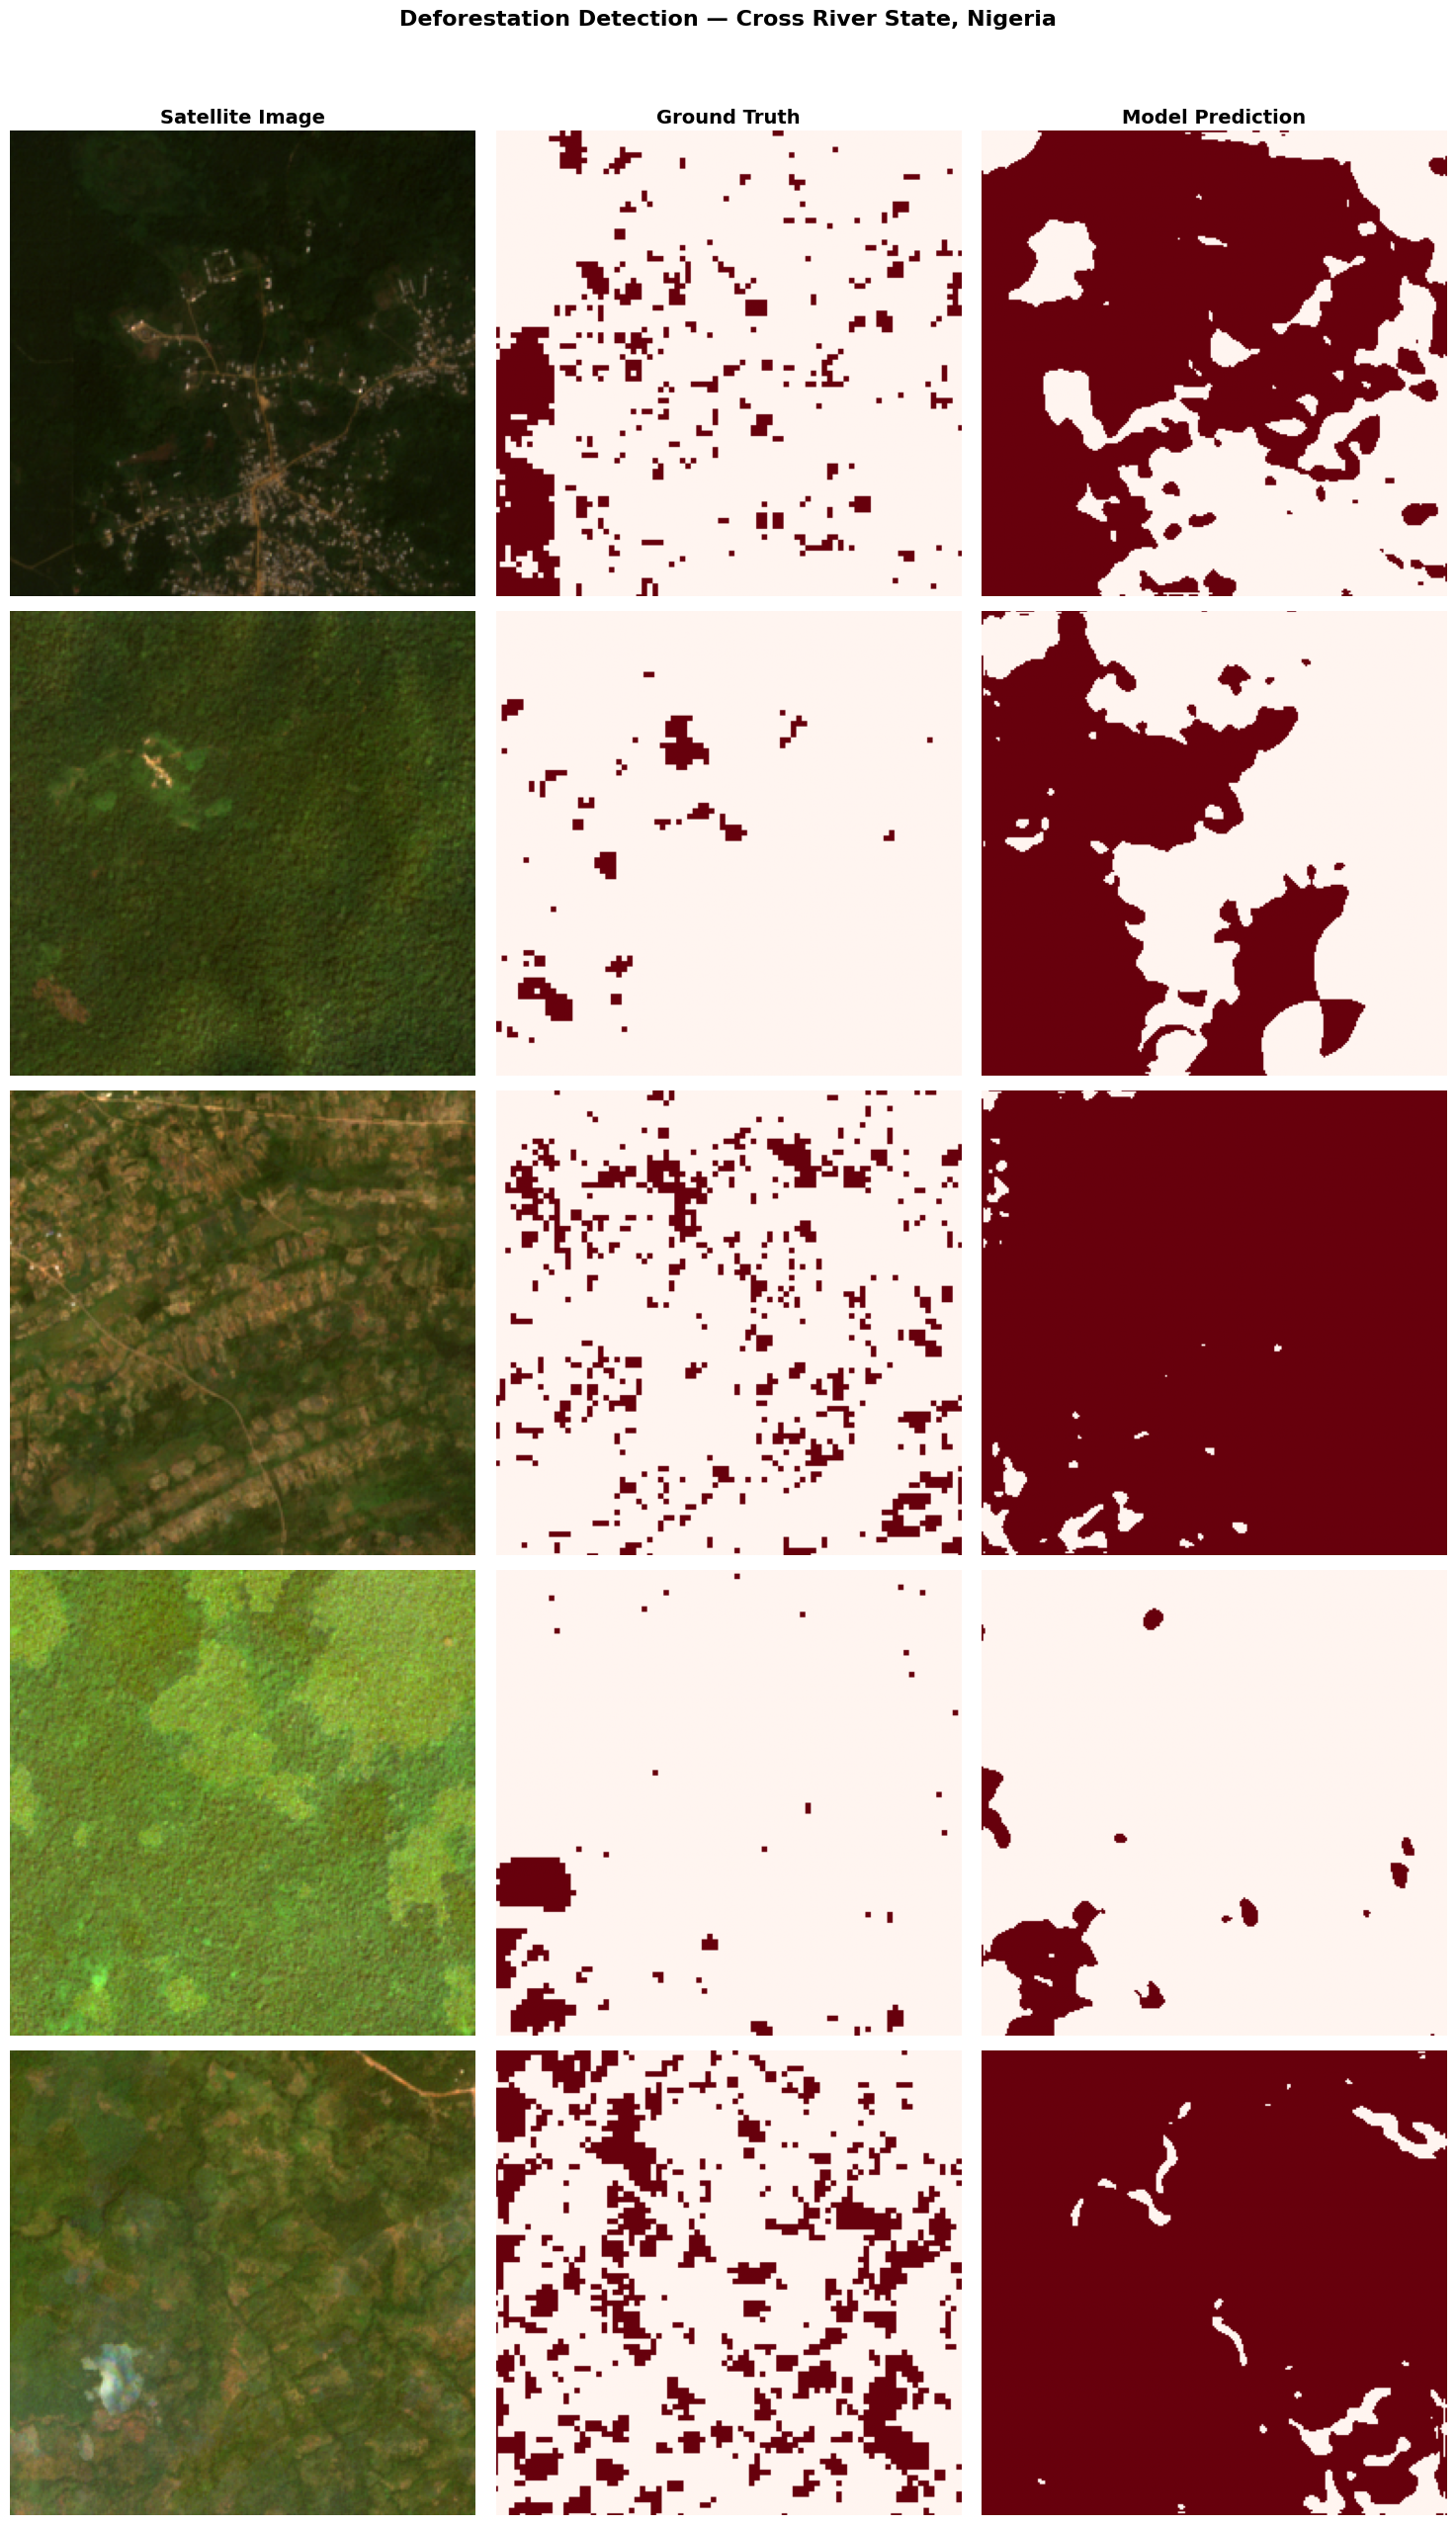

Map saved to Drive


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Get a few test patches and visualize predictions vs ground truth
fig, axes = plt.subplots(5, 3, figsize=(15, 25))
columns = ['Satellite Image', 'Ground Truth', 'Model Prediction']

for col, title in enumerate(columns):
    axes[0, col].set_title(title, fontsize=14, fontweight='bold')

model.eval()
count = 0

with torch.no_grad():
    for images, masks in test_loader:
        if count >= 5:
            break

        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        preds = torch.sigmoid(outputs) > 0.5

        # Show first image in batch
        img = images[0].cpu().numpy()
        mask = masks[0].cpu().numpy().squeeze()
        pred = preds[0].cpu().numpy().squeeze()

        # RGB from bands 1,2,3 (B4,B3,B2)
        rgb = img[1:4].transpose(1, 2, 0)
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

        axes[count, 0].imshow(rgb)
        axes[count, 0].axis('off')

        axes[count, 1].imshow(mask, cmap='Reds', vmin=0, vmax=1)
        axes[count, 1].axis('off')

        axes[count, 2].imshow(pred, cmap='Reds', vmin=0, vmax=1)
        axes[count, 2].axis('off')

        count += 1

plt.suptitle('Deforestation Detection — Cross River State, Nigeria',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/deforestation_project/outputs/maps/deforestation_predictions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Map saved to Drive")

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

# Collect samples from training patches
print("Collecting training samples...")
X_train, y_train = [], []

for i in range(0, 500):  # use 500 patches for speed
    try:
        img = np.load(f'{images_dir}/patch_{i}.npy')  # [4, 256, 256]
        mask = np.load(f'{masks_dir}/patch_{i}.npy')  # [256, 256]

        # Reshape: each pixel becomes one sample with 4 features
        pixels = img.reshape(4, -1).T  # [65536, 4]
        labels = mask.reshape(-1)       # [65536]

        X_train.append(pixels)
        y_train.append(labels)
    except:
        continue

X_train = np.vstack(X_train)
y_train = np.concatenate(y_train)

print(f"Training samples: {X_train.shape}")
print(f"Positive (deforested) samples: {y_train.sum()}")

Training samples: (32768000, 4)
Positive (deforested) samples: 1484278


In [ ]:
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',  # handles imbalance automatically
    random_state=42,
    n_jobs=-1  # use all CPU cores
)

rf.fit(X_train, y_train)
print("Training complete")

Training Random Forest...
Training complete


In [ ]:
print("Evaluating on test patches...")
X_test, y_test = [], []

for i in range(2400, 2877):  # use last patches as test set
    try:
        img = np.load(f'{images_dir}/patch_{i}.npy')
        mask = np.load(f'{masks_dir}/patch_{i}.npy')

        pixels = img.reshape(4, -1).T
        labels = mask.reshape(-1)

        X_test.append(pixels)
        y_test.append(labels)
    except:
        continue

X_test = np.vstack(X_test)
y_test = np.concatenate(y_test)

# Predict
print("Running predictions...")
y_pred = rf.predict(X_test)

# Metrics
intersection = ((y_pred == 1) & (y_test == 1)).sum()
union = ((y_pred == 1) | (y_test == 1)).sum()
iou = intersection / (union + 1e-8)

precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
accuracy = (y_pred == y_test).mean()

print(f"\nRandom Forest Results:")
print(f"IoU:       {iou:.4f}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Evaluating on test patches...
Running predictions...

Random Forest Results:
IoU:       0.1582
Accuracy:  0.5130
Precision: 0.1717
Recall:    0.6684
F1 Score:  0.2732


In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

model.load_state_dict(torch.load(
    '/content/drive/MyDrive/deforestation_project/models/best_model.pth',
    map_location=device
))
model.eval()

all_preds = []
all_masks = []

with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        preds = torch.sigmoid(outputs) > 0.5
        all_preds.append(preds.cpu().numpy().flatten())
        all_masks.append(masks.cpu().numpy().flatten())

all_preds = np.concatenate(all_preds)
all_masks = np.concatenate(all_masks)

print(f"Precision: {precision_score(all_masks, all_preds, zero_division=0):.4f}")
print(f"Recall:    {recall_score(all_masks, all_preds, zero_division=0):.4f}")
print(f"F1 Score:  {f1_score(all_masks, all_preds, zero_division=0):.4f}")

Precision: 0.2592
Recall:    0.8033
F1 Score:  0.3919
